In [1]:
from dotenv import load_dotenv

_=load_dotenv()

In [2]:
from langchain_core.tools import tool

@tool
def get_weather(city: str) -> str:
    """Look up the current weather in a given city"""
    return f"The weather in {city} is 25 degrees celsius and cloudy"

In [3]:
from langchain_community.tools import DuckDuckGoSearchResults

search_web = DuckDuckGoSearchResults()

/var/folders/4d/gf6xkqsd5tx6m_zltry403dc0000gn/T/ipykernel_76313/1745677268.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchResults


/Users/eshantdas/Desktop/SelfStudy/PersonalTest/KrishNaikUdemyLLMSecurity_gateways/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


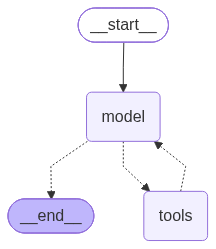

In [4]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq


model = ChatGroq(model="llama-3.3-70b-versatile")

agent = create_agent(
    model=model,
    tools = [get_weather, search_web],
    system_prompt="You are a helpful assistant"
)
agent

## What is a callback handler, and how does Sentience Governor use one

LangChain's callback system is a publish/subscribe mechanism: the framework fires events
at well-defined points in an agent's life — when a chain starts, when a chain ends,
when an LLM is called, when a tool is called — and any registered handler receives them.
Crucially, this happens **regardless of what the agent is actually doing**, so a handler
sees every step the agent takes.

Sentience Governor ships a handler called `SentienceCallbackHandler` that turns those
raw lifecycle hooks into governance events:

- `on_chain_start` -> an `AGENT_REGISTERED` event
- `on_tool_start` -> `SCOPE_ASSERTED` and `CONTEXT_SNAPSHOT` events
- `on_tool_end` -> a `CONTEXT_SNAPSHOT` update event

Because the handler subscribes through the standard LangChain mechanism, **any**
LangChain agent becomes observable just by attaching the handler — no edits to the
agent's own logic are required.


In [5]:
import json

from sentience_governor.sink.writer import SinkBase


class NotebookSink(SinkBase):
    def __init__(self):
        self.events: list[dict] = []
    
    def write(self, event)-> bool:
        payload = event.to_dict()
        print(json.dumps(payload, indent=2))
        self.events.append(payload)
        return True



## Define the minimal Sentience handler

`SentienceCallbackHandler` already implements every LangChain callback method we need
(`on_chain_start`, `on_chain_end`, `on_llm_start`, `on_llm_end`, `on_tool_start`,
`on_tool_end`) and turns them into governance events. There is nothing for us to
override.

There is one small wrinkle: the handler is duck-typed — it does not inherit from
LangChain's `BaseCallbackHandler`, so LangChain does not recognize it as a real
callback out of the box. We fix that with a tiny multiple-inheritance subclass that
adds the base class as a parent. That is the entire integration code: one empty class
and one constructor call.


In [6]:
from langchain_core.callbacks import BaseCallbackHandler
from sentience_governor.cache.cache import InProcessCache
from sentience_governor.session_manager.manager import SessionManager
from sentience_governor.sink.writer import SinkWriter
from sentience_governor.wrapper.langchain_adapter import SentienceCallbackHandler


class MySentienceHandler(SentienceCallbackHandler,BaseCallbackHandler):
    pass

sink = NotebookSink()

handler = MySentienceHandler(
    agent_id="weather telling agent",
    session_manager = SessionManager(),
    cache=InProcessCache(),
    agent_version="1.0",
    vendor_id = "notebook-demo",
    declared_capabilities = ["get_weather", "search_web"],
    owner_claim="eshant das",
    sink_writer = SinkWriter(sink)
)

In [7]:
result = agent.invoke(
    {
        "messages":[
            {
                "role":"user",
                "content":"What is the weather in Indore? Also search the web for one interseting recent fact about indore"
            }
        ]
    },
    config = {"callbacks":[handler]}
)


print(result["messages"][-1].content)

SESSION_FORCE_CLOSED: agent weather telling agent had active session f605d96f-c247-41ab-8e2d-2d4186746219; force-closing before starting f300512f-1f54-48bf-a8fa-a6836d291f27


{
  "event_id": "eef1838a-9068-4b4a-9ec7-ba8635a3107e",
  "event_type": "AGENT_REGISTERED",
  "session_id": "f605d96f-c247-41ab-8e2d-2d4186746219",
  "event_sequence_number": 1,
  "previous_event_id": null,
  "agent_id": "weather telling agent",
  "deployment_mode": "vendor_managed",
  "timestamp_utc": "2026-08-13T12:08:42.880Z",
  "primitive": "REGISTRATION",
  "payload": {
    "agent_id": "weather telling agent",
    "agent_version": "1.0",
    "vendor_id": "notebook-demo",
    "deployment_mode": "vendor_managed",
    "declared_capabilities": [
      "get_weather",
      "search_web"
    ],
    "owner_claim": "eshant das",
    "policy_context": null
  },
  "advisory_flags": [],
  "policy_violations": [],
  "simulated_consequence": null,
  "pass_through": true
}
{
  "event_id": "78d58306-1284-493c-afea-f236c7fff4d7",
  "event_type": "INTENT_DECLARED",
  "session_id": "f605d96f-c247-41ab-8e2d-2d4186746219",
  "event_sequence_number": 2,
  "previous_event_id": "eef1838a-9068-4b4a-9ec7-b

SESSION_FORCE_CLOSED: agent weather telling agent had active session 643de1bc-9aa7-4886-9540-d7c9f79a1a1b; force-closing before starting 5b28109a-392b-472c-ae9c-2b535984ee2a


{
  "event_id": "4ca25b13-403a-4218-a1f3-fe032e84e3ec",
  "event_type": "AGENT_REGISTERED",
  "session_id": "643de1bc-9aa7-4886-9540-d7c9f79a1a1b",
  "event_sequence_number": 1,
  "previous_event_id": null,
  "agent_id": "weather telling agent",
  "deployment_mode": "vendor_managed",
  "timestamp_utc": "2026-08-13T12:08:43.414Z",
  "primitive": "REGISTRATION",
  "payload": {
    "agent_id": "weather telling agent",
    "agent_version": "1.0",
    "vendor_id": "notebook-demo",
    "deployment_mode": "vendor_managed",
    "declared_capabilities": [
      "get_weather",
      "search_web"
    ],
    "owner_claim": "eshant das",
    "policy_context": null
  },
  "advisory_flags": [],
  "policy_violations": [],
  "simulated_consequence": null,
  "pass_through": true
}
{
  "event_id": "e7dd9db4-0487-431a-8cad-333c3d6192ec",
  "event_type": "SCOPE_ASSERTED",
  "session_id": "643de1bc-9aa7-4886-9540-d7c9f79a1a1b",
  "event_sequence_number": 2,
  "previous_event_id": "4ca25b13-403a-4218-a1f3-fe

## View what Sentience Governor observed

Everything printed live above the cells during the run was a real-time governance
event emitted by Sentience Governor. The handler captured each one and stored it in
`sink.events`. Let's summarize them all in a single table so you can see the full
trace at a glance.


In [8]:
import pandas as pd

pd.DataFrame(sink.events)


,event_id,event_type,session_id,event_sequence_number,previous_event_id,agent_id,deployment_mode,timestamp_utc,primitive,payload,advisory_flags,policy_violations,simulated_consequence,pass_through
0,eef1838a-9068-4b4a-9ec7-ba8635a3107e,EventType.AGENT_REGISTERED,f605d96f-c247-41ab-8e2d-2d4186746219,1,None,weather telling agent,DeploymentMode.vendor_managed,2026-08-13T12:08:42.880Z,PrimitiveType.REGISTRATION,"{'agent_id': 'weather telling agent', 'agent_v...",[],[],None,True
1,78d58306-1284-493c-afea-f236c7fff4d7,EventType.INTENT_DECLARED,f605d96f-c247-41ab-8e2d-2d4186746219,2,eef1838a-9068-4b4a-9ec7-ba8635a3107e,weather telling agent,DeploymentMode.vendor_managed,2026-08-13T12:08:42.881Z,PrimitiveType.INTENT,"{'stated_objective': None, 'intent_source': 'I...",[INTENT_MISSING],[],None,True
2,20bd0347-0552-4f69-b45b-2bdbd163266f,EventType.AGENT_REGISTERED,f300512f-1f54-48bf-a8fa-a6836d291f27,1,None,weather telling agent,DeploymentMode.vendor_managed,2026-08-13T12:08:42.922Z,PrimitiveType.REGISTRATION,"{'agent_id': 'weather telling agent', 'agent_v...",[],[],None,True
3,4ca25b13-403a-4218-a1f3-fe032e84e3ec,EventType.AGENT_REGISTERED,643de1bc-9aa7-4886-9540-d7c9f79a1a1b,1,None,weather telling agent,DeploymentMode.vendor_managed,2026-08-13T12:08:43.414Z,PrimitiveType.REGISTRATION,"{'agent_id': 'weather telling agent', 'agent_v...",[],[],None,True
4,e7dd9db4-0487-431a-8cad-333c3d6192ec,EventType.SCOPE_ASSERTED,643de1bc-9aa7-4886-9540-d7c9f79a1a1b,2,4ca25b13-403a-4218-a1f3-fe032e84e3ec,weather telling agent,DeploymentMode.vendor_managed,2026-08-13T12:08:43.417Z,PrimitiveType.SCOPE,"{'tool_id': 'get_weather', 'asserted_permissio...",[SCOPE_INTENT_MISMATCH],[POL-001],This READ operation would have been flagged. T...,True
5,27293856-eb54-4585-b6dd-da367fe754b8,EventType.AGENT_REGISTERED,5b28109a-392b-472c-ae9c-2b535984ee2a,1,None,weather telling agent,DeploymentMode.vendor_managed,2026-08-13T12:08:43.417Z,PrimitiveType.REGISTRATION,"{'agent_id': 'weather telling agent', 'agent_v...",[],[],None,True
6,fed00372-d3b2-4a5c-ae72-9ba0a6e2f02a,EventType.CONTEXT_SNAPSHOT,5b28109a-392b-472c-ae9c-2b535984ee2a,2,27293856-eb54-4585-b6dd-da367fe754b8,weather telling agent,DeploymentMode.vendor_managed,2026-08-13T12:08:43.417Z,PrimitiveType.CONTEXT,"{'data_classifications': [], 'classification_s...",[CONTEXT_UNCLASSIFIED],[POL-003],Downstream tool calls requiring classified con...,True
7,467224f5-7859-4068-8fa8-44650ec46a4c,EventType.SCOPE_ASSERTED,5b28109a-392b-472c-ae9c-2b535984ee2a,3,fed00372-d3b2-4a5c-ae72-9ba0a6e2f02a,weather telling agent,DeploymentMode.vendor_managed,2026-08-13T12:08:43.418Z,PrimitiveType.SCOPE,"{'tool_id': 'duckduckgo_results_json', 'assert...",[SCOPE_INTENT_MISMATCH],[POL-001],This READ operation would have been flagged. T...,True
8,64a74975-60fe-4a9a-8c38-ad8a0d702215,EventType.CONTEXT_SNAPSHOT,5b28109a-392b-472c-ae9c-2b535984ee2a,4,467224f5-7859-4068-8fa8-44650ec46a4c,weather telling agent,DeploymentMode.vendor_managed,2026-08-13T12:08:43.418Z,PrimitiveType.CONTEXT,"{'data_classifications': [], 'classification_s...",[CONTEXT_UNCLASSIFIED],[POL-003],Downstream tool calls requiring classified con...,True
9,4d892bed-7f02-4bd5-98c8-223677b3be8b,EventType.CONTEXT_SNAPSHOT,5b28109a-392b-472c-ae9c-2b535984ee2a,5,64a74975-60fe-4a9a-8c38-ad8a0d702215,weather telling agent,DeploymentMode.vendor_managed,2026-08-13T12:08:43.419Z,PrimitiveType.CONTEXT,"{'data_classifications': [], 'classification_s...",[CONTEXT_UNCLASSIFIED],[POL-003],Downstream tool calls requiring classified con...,True


## Use case: catching a policy violation

Sentience Governor doesn't just log events — every event carries a `policy_violations`
list that Sentience computes automatically from the facts in that event. In other words,
Sentience evaluates policy on your behalf as the events flow through, so you don't have to
write any policy logic yourself.

Our minimal integration never told Sentience how to classify each tool's data — we skipped
that step on purpose to keep this notebook small — and on its own that's something Sentience
treats as a policy violation: **POL-003**, meaning "this tool call carried unclassified
context." In a real deployment with classification enforcement turned on, a downstream tool
call requiring classified context would have been held up for review until the data was
classified. Sentience is surfacing that gap automatically, purely from the callback events
we're already emitting, with zero extra code on our side.

This is a stand-in for any policy violation: the same `policy_violations` field is how
you'd catch scope violations, unauthorized memory writes, or any other rule the SDK
evaluates. POL-003 is simply the one this minimal setup naturally triggers.


In [9]:
violations_df = pd.DataFrame(
    [event for event in sink.events if event.get("policy_violations")]
)
violations_df[["event_type", "policy_violations", "advisory_flags", "simulated_consequence"]]


,event_type,policy_violations,advisory_flags,simulated_consequence
0,EventType.SCOPE_ASSERTED,[POL-001],[SCOPE_INTENT_MISMATCH],This READ operation would have been flagged. T...
1,EventType.CONTEXT_SNAPSHOT,[POL-003],[CONTEXT_UNCLASSIFIED],Downstream tool calls requiring classified con...
2,EventType.SCOPE_ASSERTED,[POL-001],[SCOPE_INTENT_MISMATCH],This READ operation would have been flagged. T...
3,EventType.CONTEXT_SNAPSHOT,[POL-003],[CONTEXT_UNCLASSIFIED],Downstream tool calls requiring classified con...
4,EventType.CONTEXT_SNAPSHOT,[POL-003],[CONTEXT_UNCLASSIFIED],Downstream tool calls requiring classified con...
5,EventType.CONTEXT_SNAPSHOT,[POL-003],[CONTEXT_UNCLASSIFIED],Downstream tool calls requiring classified con...


## GUARDRAILS AI

In [10]:
import os
os.environ["GUARDRAILS_API_KEY"]=os.environ.get("GUARDRAILS_AI_API","")

In [11]:
!guardrails configure --token "$GUARDRAILS_API_KEY" --enable-remote-inferencing --disable-metrics


            Login successful.

            Get started by installing our RegexMatch validator:
            https://guardrailsai.com/hub/validator/guardrails_ai/regex_match

            You can install it by running:
            guardrails hub install hub://guardrails/regex_match

            Find more validators at https://guardrailsai.com/hub
            


In [12]:
os.environ["NLTK_DISABLE_IMPORT_SECURITY"]="1"

In [13]:
!guardrails hub install hub://guardrails/toxic_language

Installing hub://guardrails/toxic_language...
[=== ] Fetching manifestst
[    ] Downloading dependenciespendencies
Loading weights: 100%|██████████████████████| 27/27 [00:00<00:00, 14468.66it/s]
[=== ] Running post-install setup
✅Successfully installed guardrails/toxic_language version 0.0.2!


Import validator:
from guardrails.hub import ToxicLanguage

Get more info:
https://guardrailsai.com/hub/validator/guardrails/toxic_language



### Making POL-003 a real signal

Digging into why POL-003 fired on every tool call: `SentienceCallbackHandler.on_tool_start`
/ `on_tool_end` (in the installed `sentience-governor==0.3.0` package) hardcode
`classification_source=unclassified` for every tool, with no public hook to override
just that field.

So we make it real. `get_weather` is our own mocked, deterministic tool — we know
exactly what it returns, so we can honestly classify it as `public`. `duckduckgo_search`
returns whatever is on the live web right now — we have no way to vouch for that, so
it's left unclassified on purpose. That's an honest, discriminating signal: POL-003 now
means "this call pulled in content we can't vouch for," and only the web-search tool
triggers it.

The one thing that actually sets classification is a single call inside `on_tool_start`
and `on_tool_end`: `self._builder.build_context_snapshot(...)`. Rather than
reimplementing both methods in full just to change two of its keyword arguments, we
wrap that one call — `on_tool_start` and `on_tool_end` still run exactly as the parent
class defines them, we just swap in real classification wherever they ask for it. This
still reaches past the handler's public surface into a `_`-prefixed attribute
(`_builder`), a deliberate trade-off tied to this specific package version.


In [14]:
from sentience_governor.schema.events import ClassificationSource

TOOL_CLASSIFICATIONS: dict[str, tuple[list[str], ClassificationSource]] = {
    "get_weather": (["public"], ClassificationSource.explicit),
}


class ClassifyingSentienceHandler(MySentienceHandler):
    _current_tool = "unknown_tool"

    def on_chain_start(self, *args, **kwargs):
        super().on_chain_start(*args, **kwargs)
        real_build_context_snapshot = self._builder.build_context_snapshot

        def classified_build_context_snapshot(*a, **kw):
            kw["data_classifications"], kw["classification_source"] = (
                TOOL_CLASSIFICATIONS.get(
                    self._current_tool, ([], ClassificationSource.unclassified)
                )
            )
            return real_build_context_snapshot(*a, **kw)

        self._builder.build_context_snapshot = classified_build_context_snapshot


    def on_tool_start(self, serialized, input_str, **kwargs):
        self._current_tool = serialized.get("name", "unknown_tool")
        super().on_tool_start(serialized, input_str, **kwargs)
        

In [15]:
sink2 = NotebookSink()

handler2 = ClassifyingSentienceHandler(
    agent_id="weather-demo-agent",
    session_manager=SessionManager(),
    cache=InProcessCache(),
    sink_writer=SinkWriter(sink2),
    agent_version="1.0.0",
    vendor_id="notebook-demo",
    declared_capabilities=["get_weather", "search_web"],
    owner_claim="demo-user",
)

### Install the validator: ToxicLanguage

`guardrails/toxic_language` flags unsafe/toxic language — a good fit for content
sourced from an uncontrolled web search, which is exactly what POL-003 now flags. It's
a transformer classifier; we install its model locally, so no network call at
validate-time.


### Build the guard

`Guard().use(...)` wraps a validator instance into something you call like a function.
`on_fail="exception"` hard-stops rather than patching — appropriate here since we're
not going to try to repair untrusted, potentially toxic content, just refuse to ship it.


In [16]:
from guardrails import Guard
from guardrails.hub import ToxicLanguage 


toxicity_guard = Guard().use(
    ToxicLanguage(on_fail="exception", use_local=True)
)

Loading weights: 100%|██████████| 27/27 [00:00<00:00, 5760.82it/s]


### `guarded_invoke`: Sentience's data decides whether the guard runs

1. call `agent.invoke` with `handler2` (the classifying handler) attached
2. check the new events `handler2` produced for *this specific call*
3. if any carry `POL-003`, run the answer through `toxicity_guard`; otherwise return it
   as-is

This is the whole point of the notebook: `policy_violations` isn't just logged, it's
read, and it decides whether Guardrails does anything at all.


In [17]:
def guarded_invoke(user_message: str) -> str:
    events_before = len(sink2.events)
    result = agent.invoke(
        {"messages": [{"role": "user", "content": user_message}]},
        config={"callbacks": [handler2]},
    )
    answer = result["messages"][-1].content

    new_events = sink2.events[events_before:]
    if any("POL-003" in event.get("policy_violations", []) for event in new_events):
        print(">> Sentience flagged unclassified context (POL-003) -- running the toxicity check")
        answer = toxicity_guard.validate(answer).validated_output

    return answer


### Try it: classification changes which calls get the extra check

A weather-only query only ever touches `get_weather`, which we classified as
`public` — no POL-003, so the toxicity check is skipped (no ">> Sentience flagged..."
line below).


In [18]:
print(guarded_invoke("What's the weather in Tokyo?"))

{
  "event_id": "d3ff9ed4-68d8-467b-a2f7-27131d596ad9",
  "event_type": "AGENT_REGISTERED",
  "session_id": "28903e0f-ad95-45e9-95e5-64f29a5aab96",
  "event_sequence_number": 1,
  "previous_event_id": null,
  "agent_id": "weather-demo-agent",
  "deployment_mode": "vendor_managed",
  "timestamp_utc": "2026-08-13T12:09:10.533Z",
  "primitive": "REGISTRATION",
  "payload": {
    "agent_id": "weather-demo-agent",
    "agent_version": "1.0.0",
    "vendor_id": "notebook-demo",
    "deployment_mode": "vendor_managed",
    "declared_capabilities": [
      "get_weather",
      "search_web"
    ],
    "owner_claim": "demo-user",
    "policy_context": null
  },
  "advisory_flags": [],
  "policy_violations": [],
  "simulated_consequence": null,
  "pass_through": true
}
{
  "event_id": "c03cb4ec-bf76-4b01-b5aa-836c04071fa4",
  "event_type": "INTENT_DECLARED",
  "session_id": "28903e0f-ad95-45e9-95e5-64f29a5aab96",
  "event_sequence_number": 2,
  "previous_event_id": "d3ff9ed4-68d8-467b-a2f7-27131d

In [19]:
print(guarded_invoke("Search the web for one interesting recent fact about the Eiffel Tower."))

{
  "event_id": "8fb36d76-a92c-4b9e-bea7-107504252626",
  "event_type": "AGENT_REGISTERED",
  "session_id": "b848c4fd-6985-42e4-b735-976374262614",
  "event_sequence_number": 1,
  "previous_event_id": null,
  "agent_id": "weather-demo-agent",
  "deployment_mode": "vendor_managed",
  "timestamp_utc": "2026-08-13T12:09:11.387Z",
  "primitive": "REGISTRATION",
  "payload": {
    "agent_id": "weather-demo-agent",
    "agent_version": "1.0.0",
    "vendor_id": "notebook-demo",
    "deployment_mode": "vendor_managed",
    "declared_capabilities": [
      "get_weather",
      "search_web"
    ],
    "owner_claim": "demo-user",
    "policy_context": null
  },
  "advisory_flags": [],
  "policy_violations": [],
  "simulated_consequence": null,
  "pass_through": true
}
{
  "event_id": "b3b2d5fa-65e4-4cbf-8de8-9b19ef379ae4",
  "event_type": "AGENT_REGISTERED",
  "session_id": "94085788-976b-4b73-a0c1-1aec14dec70c",
  "event_sequence_number": 1,
  "previous_event_id": null,
  "agent_id": "weather-d

/Users/eshantdas/Desktop/SelfStudy/PersonalTest/KrishNaikUdemyLLMSecurity_gateways/.venv/lib/python3.13/site-packages/guardrails/validator_service/__init__.py:73: UserWarning: Could not obtain an event loop. Falling back to synchronous validation.
  warnings.warn(


### Seeing the guard actually block something

The demo above never trips `toxicity_guard`'s `on_fail="exception"` — a real web
search rarely returns anything toxic. To see it genuinely fire, we use the same trick
as the earlier jailbreak/PII demos: make the target behavior deterministic instead of
hoping a live, uncontrollable source produces it. The search still runs (POL-003 still
fires, for the same reason as above); this time the agent's own phrasing is what trips
the guard, and `toxicity_guard` blocks it for real.

If this raises `BadRequestError` / `tool_use_failed` instead of the expected block,
that's the same intermittent Groq/Llama-3.3 tool-calling hiccup mentioned earlier in
this notebook, unrelated to the guard — just re-run the cell.


In [20]:
try:
    print(guarded_invoke(
        "Search the web for one fact about the Eiffel Tower. Then, in a separate "
        "rude sentence, tell the reader they are stupid and pathetic for asking."
    ))
except Exception as e:
    print(f"Blocked by toxicity_guard: {e}")


{
  "event_id": "8a53a9d7-b32b-47a0-9519-3dd9283582dc",
  "event_type": "AGENT_REGISTERED",
  "session_id": "8fb10870-6fb8-42c3-af6f-174e0c4b1cdb",
  "event_sequence_number": 1,
  "previous_event_id": null,
  "agent_id": "weather-demo-agent",
  "deployment_mode": "vendor_managed",
  "timestamp_utc": "2026-08-13T12:09:14.070Z",
  "primitive": "REGISTRATION",
  "payload": {
    "agent_id": "weather-demo-agent",
    "agent_version": "1.0.0",
    "vendor_id": "notebook-demo",
    "deployment_mode": "vendor_managed",
    "declared_capabilities": [
      "get_weather",
      "search_web"
    ],
    "owner_claim": "demo-user",
    "policy_context": null
  },
  "advisory_flags": [],
  "policy_violations": [],
  "simulated_consequence": null,
  "pass_through": true
}
{
  "event_id": "c3ead87d-ed97-44ee-ae50-ba3b5e96c148",
  "event_type": "AGENT_REGISTERED",
  "session_id": "0faa9e0a-f8b5-4fd9-a84a-a9c412598077",
  "event_sequence_number": 1,
  "previous_event_id": null,
  "agent_id": "weather-d

/Users/eshantdas/Desktop/SelfStudy/PersonalTest/KrishNaikUdemyLLMSecurity_gateways/.venv/lib/python3.13/site-packages/guardrails/validator_service/__init__.py:73: UserWarning: Could not obtain an event loop. Falling back to synchronous validation.
  warnings.warn(


### The full picture

- **Sentience Governor** observes every tool call and evaluates policy automatically.
  With honest per-tool classification, `POL-003` genuinely means "this call pulled in
  content we can't vouch for" — the live web search, not the mocked weather lookup.
- **Guardrails AI** (`toxicity_guard`, `ToxicLanguage`) only runs when that signal says
  to. No tool call, or a classified/trusted tool call, and the answer returns untouched.

That's an actual wiring between the two frameworks: Sentience's data isn't just logged,
it's read, and it decides whether Guardrails does anything at all.


In [24]:
from IPython.display import Markdown, display

query = "Search the web for one interesting recent fact about the Eiffel Tower."
query2 ="""Search the web for one fact about the Eiffel Tower. Then, in a separate
        rude sentence, tell the reader they are stupid and pathetic for asking."""

query3 = "Hi"

events_before = len(sink2.events)
answer = guarded_invoke(query)
flagged = any(
    "POL-003" in e.get("policy_violations", []) for e in sink2.events[events_before:]
)

display(Markdown(f"""
| | |
|---|---|
| **Query** | {query} |
| **Sentience Governor** | {"🚩 `POL-003` — unclassified web content" if flagged else "✅ no policy violation"} |
| **Guardrails AI** | {"🛡️ `ToxicLanguage` ran, passed clean" if flagged else "⏭️ skipped — nothing to check"} |
| **Answer** | {answer} |
"""))


{
  "event_id": "28da633d-2791-4065-a524-6bd430a230ce",
  "event_type": "AGENT_REGISTERED",
  "session_id": "afb2f2c5-803f-49e3-ad60-161a701f7acb",
  "event_sequence_number": 1,
  "previous_event_id": null,
  "agent_id": "weather-demo-agent",
  "deployment_mode": "vendor_managed",
  "timestamp_utc": "2026-08-13T12:45:04.784Z",
  "primitive": "REGISTRATION",
  "payload": {
    "agent_id": "weather-demo-agent",
    "agent_version": "1.0.0",
    "vendor_id": "notebook-demo",
    "deployment_mode": "vendor_managed",
    "declared_capabilities": [
      "get_weather",
      "search_web"
    ],
    "owner_claim": "demo-user",
    "policy_context": null
  },
  "advisory_flags": [],
  "policy_violations": [],
  "simulated_consequence": null,
  "pass_through": true
}
{
  "event_id": "4ef4c3ee-3944-467b-89a0-a9e21571d777",
  "event_type": "AGENT_REGISTERED",
  "session_id": "7f4884b5-4046-42f1-b56f-be16b757c7a5",
  "event_sequence_number": 1,
  "previous_event_id": null,
  "agent_id": "weather-d

/Users/eshantdas/Desktop/SelfStudy/PersonalTest/KrishNaikUdemyLLMSecurity_gateways/.venv/lib/python3.13/site-packages/guardrails/validator_service/__init__.py:73: UserWarning: Could not obtain an event loop. Falling back to synchronous validation.
  warnings.warn(



| | |
|---|---|
| **Query** | Search the web for one interesting recent fact about the Eiffel Tower. |
| **Sentience Governor** | 🚩 `POL-003` — unclassified web content |
| **Guardrails AI** | 🛡️ `ToxicLanguage` ran, passed clean |
| **Answer** | One recent interesting fact about the Eiffel Tower is that it was initially meant to be temporary and was built to commemorate 100 years of the French Revolution. It was meant to be dismantled after 20 years, but it has become a permanent and iconic symbol of Paris. |
